
# Hessian以及training监控计算



统一符号，避免混淆。

**维度**

- 输出空间维度：$m$
- 参数空间维度：$p$

**基本对象**

- 参数向量：

$$\mathbf w \in \mathbb R^p$$

- 网络输出：

$$\mathbf y(\mathbf w)\in \mathbb R^m$$

- 目标标签：

$$\hat{\mathbf y}\in\mathbb R^m$$

- 残差：

$$\mathbf r(\mathbf w)=\mathbf y(\mathbf w)-\hat{\mathbf y}\in\mathbb R^m$$

- 平方损失：

$$\mathcal L(\mathbf w)=\frac12\|\mathbf r(\mathbf w)\|^2 =\frac12\sum_{i=1}^m r_i(\mathbf w)^2$$

**Jacobian**

定义输出对参数的 Jacobian：

$$\mathbf J = \frac{\partial \mathbf y}{\partial \mathbf w^\top} \in \mathbb R^{m\times p}$$

其中第 $i$ 行是

$$\frac{\partial y_i}{\partial \mathbf w^\top}$$

写成矩阵的样子：

$$\mathbf J = \begin{bmatrix} \dfrac{\partial y_1}{\partial w_1} & \dfrac{\partial y_1}{\partial w_2} & \cdots & \dfrac{\partial y_1}{\partial w_p} \\[6pt] \dfrac{\partial y_2}{\partial w_1} & \dfrac{\partial y_2}{\partial w_2} & \cdots & \dfrac{\partial y_2}{\partial w_p} \\[6pt] \vdots & \vdots & \ddots & \vdots \\[6pt] \dfrac{\partial y_m}{\partial w_1} & \dfrac{\partial y_m}{\partial w_2} & \cdots & \dfrac{\partial y_m}{\partial w_p} \end{bmatrix}_{m \times p}$$


所以：

- $\mathbf r$ 活在 **输出空间**
- $\nabla_{\mathbf w}\mathcal L$ 活在 **参数空间**

而 $\mathbf J^\top$ 的作用，就是把“输出空间的量”映射回“参数空间”。

**Hessian**

损失对参数的 Hessian 定义为

$$\mathbf H = \nabla_{\mathbf w}^2 \mathcal L = \frac{\partial^2 \mathcal L}{\partial \mathbf w\,\partial \mathbf w^\top} \in\mathbb R^{p\times p}$$
写成矩阵的样子：

$$\mathbf H = \begin{bmatrix} \dfrac{\partial^2 \mathcal L}{\partial w_1^2} & \dfrac{\partial^2 \mathcal L}{\partial w_1\,\partial w_2} & \cdots & \dfrac{\partial^2 \mathcal L}{\partial w_1\,\partial w_p} \\[6pt] \dfrac{\partial^2 \mathcal L}{\partial w_2\,\partial w_1} & \dfrac{\partial^2 \mathcal L}{\partial w_2^2} & \cdots & \dfrac{\partial^2 \mathcal L}{\partial w_2\,\partial w_p} \\[6pt] \vdots & \vdots & \ddots & \vdots \\[6pt] \dfrac{\partial^2 \mathcal L}{\partial w_p\,\partial w_1} & \dfrac{\partial^2 \mathcal L}{\partial w_p\,\partial w_2} & \cdots & \dfrac{\partial^2 \mathcal L}{\partial w_p^2} \end{bmatrix}_{p \times p}$$





## 数据流


```text
参数空间 R^p -- y(w) -->  输出空间 R^m  -- 与 y_hat 比较 -->  标量损失 L

w -----------------------> y(w) -------------------------------> L
                Jacobian J = ∂y/∂w^T
```

反向传播时，梯度流动方向是：

```text
L  -->  r = y - y_hat  -->  J^T r
      (输出空间)          (映射回参数空间)
```

因为：

- $\mathbf r \in \mathbb R^{m\times 1}$
- $\mathbf J \in \mathbb R^{m\times p}$

我们想得到的梯度必须在参数空间里，也就是：

$$\nabla_{\mathbf w}\mathcal L\in \mathbb R^{p\times 1}$$

只有

$$\mathbf J^\top \mathbf r$$

的维度才对：

$$(p\times m)(m\times 1)=p\times 1$$


> **输出梯度要通过 Jacobian 反向映射回参数空间。**



## 一阶导：$\nabla_{\mathbf w}\mathcal L = J^\top r$

从损失出发：

$$\mathcal L(\mathbf w) = \frac12 \mathbf r(\mathbf w)^\top \mathbf r(\mathbf w)$$

其中

$$\mathbf r(\mathbf w)=\mathbf y(\mathbf w)-\hat{\mathbf y}$$

因为 $\hat{\mathbf y}$ 是常数，所以

$$\frac{\partial \mathbf r}{\partial \mathbf w^\top} = \frac{\partial \mathbf y}{\partial \mathbf w^\top} = \mathbf J$$


### 分量形式推导

把损失写成和：

$$\mathcal L(\mathbf w)=\frac12\sum_{i=1}^m r_i(\mathbf w)^2$$

对 $\mathbf w$ 求导：

$$\nabla_{\mathbf w}\mathcal L = \frac12 \sum_{i=1}^m 2r_i \nabla_{\mathbf w} r_i = \sum_{i=1}^m r_i \nabla_{\mathbf w} r_i$$

又因为

$$r_i = y_i - \hat y_i,\qquad \hat y_i \text{ 是常数}$$

所以

$$\nabla_{\mathbf w} r_i = \nabla_{\mathbf w} y_i$$

于是：

$$\nabla_{\mathbf w}\mathcal L = \sum_{i=1}^m r_i \nabla_{\mathbf w} y_i$$


其中：

- $y(\mathbf w) \in \mathbb R^m$：输出有 $m$ 维
- $r_i = \frac{\partial \mathcal L}{\partial y_i}$：loss 对第 $i$ 个输出的导数（标量）
- $\nabla_{\mathbf w} y_i \in \mathbb R^p$：第 $i$ 个输出对参数 $\mathbf w$ 的梯度（$p$ 维向量）

所以每一项 $r_i \nabla_{\mathbf w} y_i$ 都是一个 $p$ 维向量，把这 $m$ 个向量加起来（每一行有m列），得到总梯度：

$$\nabla_{\mathbf w}\mathcal L \in \mathbb R^p$$
把这些行向量堆叠起来，就是矩阵形式：

$$\boxed{ \nabla_{\mathbf w}\mathcal L = \mathbf J^\top \mathbf r }$$


### 维度检查

- $\mathbf J \in \mathbb R^{m\times p}$
- $\mathbf J^\top \in \mathbb R^{p\times m}$
- $\mathbf r \in \mathbb R^{m\times 1}$

所以

$$\mathbf J^\top \mathbf r \in \mathbb R^{p\times 1}$$

正好是参数梯度的形状。



## 二阶导

从一阶导开始：

$$\nabla_{\mathbf w}\mathcal L=\mathbf J^\top \mathbf r$$

现在再对 $\mathbf w$ 求导。

注意这里 **两个东西都依赖于 $\mathbf w$**：

- $\mathbf J = \frac{\partial \mathbf y}{\partial \mathbf w^\top}$
- $\mathbf r = \mathbf y - \hat{\mathbf y}$

所以必须用乘积求导

### 分量展开
已经知道：

$$\nabla_{\mathbf w}\mathcal L = \sum_{i=1}^m r_i \nabla_{\mathbf w} y_i$$

再求一次导：

$$\mathbf H = \nabla_{\mathbf w}^2 \mathcal L = \sum_{i=1}^m \nabla_{\mathbf w}\big(r_i \nabla_{\mathbf w} y_i\big)$$

对每一项使用乘积法则：

$$\nabla_{\mathbf w}\big(r_i \nabla_{\mathbf w} y_i\big) = (\nabla_{\mathbf w} r_i)(\nabla_{\mathbf w} y_i)^\top + r_i \nabla_{\mathbf w}^2 y_i$$

而

$$\nabla_{\mathbf w} r_i = \nabla_{\mathbf w} y_i$$

所以：

$$\mathbf H = \sum_{i=1}^m \left[ (\nabla_{\mathbf w} y_i)(\nabla_{\mathbf w} y_i)^\top + r_i \nabla_{\mathbf w}^2 y_i \right]$$

第一项就是 $J^\top J$，于是：

$$\boxed{ \mathbf H = \mathbf J^\top \mathbf J + \sum_{i=1}^m r_i \nabla_{\mathbf w}^2 y_i }$$


### 解释

- $\mathbf J^\top \mathbf J$：来自“残差平方”这个外层二次形式
- $\sum_i r_i \nabla_{\mathbf w}^2 y_i$：来自“输出本身对参数已经是弯的”

所以：

> **如果输出 $y_i(\mathbf w)$ 本身是非线性的，那么它自己的曲率也会进入 Hessian。**



### 线性层里第二项消失

如果网络输出对参数是线性的，例如：

$$\mathbf y(\mathbf w)=\mathbf A \mathbf w$$

那么每个分量 $y_i(\mathbf w)$ 都是关于 $\mathbf w$ 的线性函数。

线性函数的二阶导恒为 0：

$$\nabla_{\mathbf w}^2 y_i = 0$$

于是 Hessian 的完整公式里第二项直接消失：

$$\sum_{i=1}^m r_i \nabla_{\mathbf w}^2 y_i = 0$$

因此得到：

$$\boxed{ \mathbf H = \mathbf J^\top \mathbf J }$$


**总结**

> **平方损失下，Hessian 一般等于“Gauss-Newton 项 + 输出自身的二阶项”。**  
> 在线性层里，输出对参数没有二阶曲率，所以只剩下 $J^\top J$。



### 曲率随输入能量的变化
对于标量输出线性层：

$$y = \mathbf w^\top \mathbf x$$

其 Hessian 为：

$$\mathbf H = \mathbf x\mathbf x^\top$$

因此：

$$\operatorname{tr}(\mathbf H)=\|\mathbf x\|^2$$

也就是说，当输入整体缩放为 $a\mathbf x$ 时，Hessian 会变成：

$$\mathbf H'=(a\mathbf x)(a\mathbf x)^\top=a^2\mathbf x\mathbf x^\top$$

曲率按 $a^2$ 放大。


## 工程验证：$2 \times 3$ 线性层具体例子

从这里开始，用一个完整可算的例子，逐步验证前面推导的所有公式。

设输入：

$$\mathbf x= \begin{bmatrix} 2\\ 3\\ 1 \end{bmatrix} \in\mathbb R^3$$

设权重矩阵：

$$\mathbf W= \begin{bmatrix} w_{11} & w_{12} & w_{13}\\ w_{21} & w_{22} & w_{23} \end{bmatrix} \in\mathbb R^{2\times 3}$$

维度：$m=2$（输出），$n=3$（输入），$p=6$（参数个数）。

输出：

$$\mathbf y=\mathbf W\mathbf x = \begin{bmatrix} 2w_{11}+3w_{12}+w_{13}\\ 2w_{21}+3w_{22}+w_{23} \end{bmatrix}$$

目标向量取：

$$\hat{\mathbf y} = \begin{bmatrix} 1\\ -1 \end{bmatrix}$$


### vec 矢量化

因为 Hessian 必须对"参数向量"定义，所以先把矩阵参数拉直：

$$\mathbf w=\operatorname{vec}(\mathbf W) = \begin{bmatrix} w_{11}\\ w_{21}\\ w_{12}\\ w_{22}\\ w_{13}\\ w_{23} \end{bmatrix} \in\mathbb R^6$$

这样 Hessian 就是一个 $6\times 6$ 矩阵。


In [4]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

x = np.array([[2.0],[3.0],[1.0]])  # shape (3,1)
y_hat = np.array([[1.0],[-1.0]])

def vec_col_major(W):
    return W.reshape(-1, order="F").reshape(-1,1)

def unvec_col_major(w):
    return w.reshape((2,3), order="F")

W = np.array([[0.4, -0.2, 0.5],
              [0.1,  0.3, -0.1]])

w = vec_col_major(W)
y = W @ x
r = y - y_hat

print("x shape:", x.shape)
print("W shape:", W.shape)
print("w = vec(W) shape:", w.shape)
print("y shape:", y.shape)
print("r shape:", r.shape)
print("\nW =\n", W)
print("\nw = vec(W) =\n", w)
print("\ny = W x =\n", y)
print("\nr = y - y_hat =\n", r)


x shape: (3, 1)
W shape: (2, 3)
w = vec(W) shape: (6, 1)
y shape: (2, 1)
r shape: (2, 1)

W =
 [[ 0.4 -0.2  0.5]
 [ 0.1  0.3 -0.1]]

w = vec(W) =
 [[ 0.4]
 [ 0.1]
 [-0.2]
 [ 0.3]
 [ 0.5]
 [-0.1]]

y = W x =
 [[0.7]
 [1. ]]

r = y - y_hat =
 [[-0.3]
 [ 2. ]]



### vec-trick：把线性层写成 $y = (x^\top \otimes I)\,w$
维度

- $\mathbf x^\top \in \mathbb R^{1\times n}$
- $\mathbf I_m \in \mathbb R^{m\times m}$

那么：

$$\mathbf x^\top \otimes \mathbf I_m \in \mathbb R^{m\times mn}$$

在我们的例子里，$m=2, n=3$，所以 $p = mn = 6$：

$$\mathbf x^\top \otimes \mathbf I_2 = \begin{bmatrix} 2 & 0 & 3 & 0 & 1 & 0\\ 0 & 2 & 0 & 3 & 0 & 1 \end{bmatrix} \in \mathbb R^{2\times 6}$$

然后：

$$\mathbf y = (\mathbf x^\top \otimes \mathbf I_2)\mathbf w$$

这一步只是把"矩阵乘向量"的线性层，改写成"矩阵乘参数向量"的标准形式。


In [5]:

Im = np.eye(2)
A = np.kron(x.T, Im)   # shape (2,6)

print("A = x^T ⊗ I =\n", A)
print("\nA shape:", A.shape)

y_from_vec = A @ w
print("\nA @ w =\n", y_from_vec)
print("\nMatches W @ x ?", np.allclose(y_from_vec, y))


A = x^T ⊗ I =
 [[2. 0. 3. 0. 1. 0.]
 [0. 2. 0. 3. 0. 1.]]

A shape: (2, 6)

A @ w =
 [[0.7]
 [1. ]]

Matches W @ x ? True



### $J = x^\top \otimes I$

因为已经有：

$$\mathbf y = \mathbf A \mathbf w, \qquad \mathbf A = \mathbf x^\top \otimes \mathbf I_m$$

而对于线性函数：

$$\frac{\partial (\mathbf A\mathbf w)}{\partial \mathbf w^\top} = \mathbf A$$

所以：

$$\boxed{ \mathbf J = \frac{\partial \mathbf y}{\partial \mathbf w^\top} = \mathbf x^\top \otimes \mathbf I_m }$$

在这个例子里：

$$\mathbf J= \begin{bmatrix} 2 & 0 & 3 & 0 & 1 & 0\\ 0 & 2 & 0 & 3 & 0 & 1 \end{bmatrix}$$

维度是 $2\times 6$。


In [6]:

J = A.copy()
print("J =\n", J)
print("J shape:", J.shape)

grad = J.T @ r
print(f"{r=}")
print(f"J^T r ={grad}")
print(f"Gradient shape:{grad.shape}")


J =
 [[2. 0. 3. 0. 1. 0.]
 [0. 2. 0. 3. 0. 1.]]
J shape: (2, 6)
r=array([[-0.3],
       [ 2. ]])
J^T r =[[-0.6]
 [ 4. ]
 [-0.9]
 [ 6. ]
 [-0.3]
 [ 2. ]]
Gradient shape:(6, 1)



### 梯度一定是 $J^\top r$

在这个例子里：

- $\mathbf J \in \mathbb R^{2\times 6}$
- $\mathbf r \in \mathbb R^{2\times 1}$

所以：

$$\mathbf J^\top \mathbf r \in \mathbb R^{6\times 1}$$

这正好和参数向量

$$\mathbf w\in\mathbb R^6$$

的形状一致。

如果不用转置，直接写 $Jr$，那维度根本乘不上：

$$(2\times 6)(2\times 1)$$

这是不合法的。

所以这里的转置，是由"**梯度最终必须回到参数空间**"强制决定的。



### 从偏导定义手算 Hessian
用 $\mathbf W \in \mathbb R^{2 \times 3}$ 的例子，$m=2,\; n=3,\; p=6$。

经过 vec-trick 展开后，已知一阶导（梯度）的 6 个分量：

$$\nabla_{\mathbf w}\mathcal L = \mathbf J^\top \mathbf r = \begin{bmatrix} r_1 x_1 \\ r_2 x_1 \\ r_1 x_2 \\ r_2 x_2 \\ r_1 x_3 \\ r_2 x_3 \end{bmatrix}$$

其中 $r_1 = y_1 - \hat{y}_1 = w_{11}x_1 + w_{12}x_2 + w_{13}x_3 - \hat{y}_1$，$r_2 = w_{21}x_1 + w_{22}x_2 + w_{23}x_3 - \hat{y}_2$。

Hessian 的定义：对梯度的每个分量，再对每个参数求偏导。

---

**第 1 个梯度分量** $g_1 = r_1 x_1$

$r_1$ 依赖 $w_{11}, w_{12}, w_{13}$（第 1 行参数），不依赖 $w_{21}, w_{22}, w_{23}$（第 2 行参数）。

$$\begin{aligned}
\frac{\partial g_1}{\partial w_{11}} &= \frac{\partial (r_1 x_1)}{\partial w_{11}} = x_1 \frac{\partial r_1}{\partial w_{11}} = x_1 \cdot x_1 = x_1^2 \\
\frac{\partial g_1}{\partial w_{21}} &= x_1 \frac{\partial r_1}{\partial w_{21}} = x_1 \cdot 0 = 0 \\
\frac{\partial g_1}{\partial w_{12}} &= x_1 \frac{\partial r_1}{\partial w_{12}} = x_1 \cdot x_2 = x_1 x_2 \\
\frac{\partial g_1}{\partial w_{22}} &= x_1 \frac{\partial r_1}{\partial w_{22}} = x_1 \cdot 0 = 0 \\
\frac{\partial g_1}{\partial w_{13}} &= x_1 \frac{\partial r_1}{\partial w_{13}} = x_1 \cdot x_3 = x_1 x_3 \\
\frac{\partial g_1}{\partial w_{23}} &= x_1 \frac{\partial r_1}{\partial w_{23}} = x_1 \cdot 0 = 0
\end{aligned}$$

Hessian 第 1 行：$\begin{bmatrix} x_1^2 & 0 & x_1 x_2 & 0 & x_1 x_3 & 0 \end{bmatrix}$

所有第 2 行参数的偏导都是 0，因为 **$r_1$ 不依赖第 2 行参数**。

---

**第 2 个梯度分量** $g_2 = r_2 x_1$

$r_2$ 依赖 $w_{21}, w_{22}, w_{23}$，不依赖 $w_{11}, w_{12}, w_{13}$。

$$\begin{aligned}
\frac{\partial g_2}{\partial w_{11}} &= x_1 \frac{\partial r_2}{\partial w_{11}} = x_1 \cdot 0 = 0 \\
\frac{\partial g_2}{\partial w_{21}} &= x_1 \frac{\partial r_2}{\partial w_{21}} = x_1 \cdot x_1 = x_1^2 \\
\frac{\partial g_2}{\partial w_{12}} &= x_1 \frac{\partial r_2}{\partial w_{12}} = x_1 \cdot 0 = 0 \\
\frac{\partial g_2}{\partial w_{22}} &= x_1 \frac{\partial r_2}{\partial w_{22}} = x_1 \cdot x_2 = x_1 x_2 \\
\frac{\partial g_2}{\partial w_{13}} &= x_1 \frac{\partial r_2}{\partial w_{13}} = x_1 \cdot 0 = 0 \\
\frac{\partial g_2}{\partial w_{23}} &= x_1 \frac{\partial r_2}{\partial w_{23}} = x_1 \cdot x_3 = x_1 x_3
\end{aligned}$$

Hessian 第 2 行：$\begin{bmatrix} 0 & x_1^2 & 0 & x_1 x_2 & 0 & x_1 x_3 \end{bmatrix}$

和第 1 行**数值完全相同**，只是 0 和非零的位置交换了（第 1 行在奇数位非零，第 2 行在偶数位非零）。

---

**第 3 个梯度分量** $g_3 = r_1 x_2$

$$\begin{aligned}
\frac{\partial g_3}{\partial w_{11}} &= x_2 \cdot x_1 = x_1 x_2 \\
\frac{\partial g_3}{\partial w_{21}} &= x_2 \cdot 0 = 0 \\
\frac{\partial g_3}{\partial w_{12}} &= x_2 \cdot x_2 = x_2^2 \\
\frac{\partial g_3}{\partial w_{22}} &= x_2 \cdot 0 = 0 \\
\frac{\partial g_3}{\partial w_{13}} &= x_2 \cdot x_3 = x_2 x_3 \\
\frac{\partial g_3}{\partial w_{23}} &= x_2 \cdot 0 = 0
\end{aligned}$$

Hessian 第 3 行：$\begin{bmatrix} x_1 x_2 & 0 & x_2^2 & 0 & x_2 x_3 & 0 \end{bmatrix}$

---

第 4-6 行同理，最终得到：

$$\mathbf H = \begin{bmatrix} x_1^2 & 0 & x_1 x_2 & 0 & x_1 x_3 & 0 \\ 0 & x_1^2 & 0 & x_1 x_2 & 0 & x_1 x_3 \\ x_1 x_2 & 0 & x_2^2 & 0 & x_2 x_3 & 0 \\ 0 & x_1 x_2 & 0 & x_2^2 & 0 & x_2 x_3 \\ x_1 x_3 & 0 & x_2 x_3 & 0 & x_3^2 & 0 \\ 0 & x_1 x_3 & 0 & x_2 x_3 & 0 & x_3^2 \end{bmatrix}$$

---

**关键观察**：整个推导过程中从未用过 $J^\top J$ 公式。$m$ 消失的原因是：

- $g_1 = r_1 x_1$ 中的 $r_1$ 只依赖第 1 行参数 → 对第 2 行参数求偏导 = 0
- $g_2 = r_2 x_1$ 中的 $r_2$ 只依赖第 2 行参数 → 对第 1 行参数求偏导 = 0

每个 $r_i$ 只和 $\mathbf W$ 的第 $i$ 行有关，所以**不同输出通道的参数之间二阶偏导为零**，这就是块对角结构 $(\mathbf x \mathbf x^\top) \otimes \mathbf I_m$ 的物理来源。



### 用 $J^\top J$ 验证手算结果

上面我们从偏导定义手算出了 Hessian。现在用矩阵公式验证。

因为输出对参数是线性的：

$$\nabla_{\mathbf w}^2 y_i = 0$$

所以完整 Hessian 的第二项消失，直接得到：

$$\mathbf H = \mathbf J^\top \mathbf J$$

并且由于 $\mathbf J = \mathbf x^\top \otimes \mathbf I_m$：

$$\mathbf H = (\mathbf x\mathbf x^\top)\otimes \mathbf I_m$$

下面用代码确认：手算的 Hessian = $J^\top J$ = $(xx^\top)\otimes I$。


In [7]:

H = J.T @ J
xxT = x @ x.T
H_from_kron = np.kron(xxT, np.eye(2))

print("x x^T =\n", xxT)
print("\nH = J^T J =\n", H)
print("\n(xx^T) ⊗ I =\n", H_from_kron)
print("\nTwo formulas match ?", np.allclose(H, H_from_kron))

print("\ntrace(H) =", np.trace(H))
print("m * ||x||^2 =", 2 * float(np.sum(x**2)))


x x^T =
 [[4. 6. 2.]
 [6. 9. 3.]
 [2. 3. 1.]]

H = J^T J =
 [[4. 0. 6. 0. 2. 0.]
 [0. 4. 0. 6. 0. 2.]
 [6. 0. 9. 0. 3. 0.]
 [0. 6. 0. 9. 0. 3.]
 [2. 0. 3. 0. 1. 0.]
 [0. 2. 0. 3. 0. 1.]]

(xx^T) ⊗ I =
 [[4. 0. 6. 0. 2. 0.]
 [0. 4. 0. 6. 0. 2.]
 [6. 0. 9. 0. 3. 0.]
 [0. 6. 0. 9. 0. 3.]
 [2. 0. 3. 0. 1. 0.]
 [0. 2. 0. 3. 0. 1.]]

Two formulas match ? True

trace(H) = 28.0
m * ||x||^2 = 28.0



### 推导 $\operatorname{tr}(H)=m\|x\|^2$

因为

$$\mathbf H = (\mathbf x\mathbf x^\top)\otimes \mathbf I_m$$

而 Kronecker 积的 trace 满足：

$$\operatorname{tr}(A\otimes B)=\operatorname{tr}(A)\operatorname{tr}(B)$$

所以：

$$\operatorname{tr}(\mathbf H) = \operatorname{tr}(\mathbf x\mathbf x^\top)\operatorname{tr}(\mathbf I_m)$$

又因为：

$$\operatorname{tr}(\mathbf x\mathbf x^\top)=\|\mathbf x\|^2$$

$$\operatorname{tr}(\mathbf I_m)=m$$

因此：

$$\boxed{\operatorname{tr}(\mathbf H)=m\|\mathbf x\|^2}$$

这说明：

> 在线性层 + 平方损失下，Hessian trace 的大小直接由输入能量控制，并且会被输出维度 $m$ 复制放大。



### 线性层损失面是二次曲面

为方便画图，先只看一个更小的标量输出例子：

$$y = w_1 x_1 + w_2 x_2$$

取：

$$x = \begin{bmatrix}2\\3\end{bmatrix},\qquad \hat y = 1$$

则损失为：

$$\mathcal L(w_1,w_2) = \frac12(2w_1+3w_2-1)^2$$

这是参数空间里的一个二次函数，所以它的等高线一定是椭圆/退化椭圆方向。



In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

w1 = np.linspace(-1.5, 1.5, 200)
w2 = np.linspace(-1.5, 1.5, 200)
W1, W2 = np.meshgrid(w1, w2)
L = 0.5 * (2*W1 + 3*W2 - 1)**2

# Analytic optimum: 2w1+3w2=1, minimum norm solution
w1_star = 2/13
w2_star = 3/13

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "surface"}, {"type": "contour"}]],
    subplot_titles=("3D Loss Surface", "Contour (等高线)"),
    horizontal_spacing=0.08,
)

fig.add_trace(
    go.Surface(x=W1, y=W2, z=L, colorscale="Viridis",
              showscale=False, opacity=0.9),
    row=1, col=1,
)
fig.update_scenes(dict(
    xaxis_title="w\u2081", yaxis_title="w\u2082", zaxis_title="L(w\u2081,w\u2082)"),
    row=1, col=1,
)

fig.add_trace(
    go.Contour(x=w1, y=w2, z=L, colorscale="Viridis",
              ncontours=25, showscale=False,
              contours=dict(showlabels=True,
                            labelfont=dict(size=10, color="white"))),
    row=1, col=2,
)
fig.add_trace(
    go.Scatter(x=[w1_star], y=[w2_star], mode="markers+text",
              marker=dict(size=10, color="red", symbol="star"),
              text=["optimum"], textposition="top center",
              textfont=dict(color="red", size=12),
              showlegend=False),
    row=1, col=2,
)
fig.update_xaxes(title_text="w\u2081", row=1, col=2)
fig.update_yaxes(title_text="w\u2082", row=1, col=2)

fig.update_layout(height=450, width=950,
                  margin=dict(l=20, r=20, t=40, b=20))
fig.show()



### 有限差分检查 $H = J^\top J$

下面我们用数值方式确认解析 Hessian 确实正确。

方法：

- 把损失当成 $\mathcal L(\mathbf w)$
- 用有限差分近似 Hessian
- 和解析解 $J^\top J$ 比较


In [9]:

def loss_from_w(w_vec):
    Wm = unvec_col_major(w_vec.reshape(-1,1))
    yv = Wm @ x
    rv = yv - y_hat
    return float(0.5 * np.sum(rv**2))

def grad_from_w(w_vec):
    Wm = unvec_col_major(w_vec.reshape(-1,1))
    yv = Wm @ x
    rv = yv - y_hat
    return (A.T @ rv).reshape(-1)  # gradient, shape (p,)

# Central finite difference: H[:,i] ≈ (∇L(w+εeᵢ) - ∇L(w-εeᵢ)) / 2ε
# Each iteration computes one column of the p×p Hessian
# Total cost: 2p gradient evaluations
def numerical_hessian(f, w0, eps=1e-5):
    n = len(w0)
    Hn = np.zeros((n,n))
    for i in range(n):
        ei = np.zeros(n); ei[i] = eps   # standard basis vector eᵢ, scaled by ε
        gp = grad_from_w(w0 + ei)       # ∇L(w + εeᵢ), shape (p,)
        gm = grad_from_w(w0 - ei)       # ∇L(w - εeᵢ), shape (p,)
        Hn[:, i] = (gp - gm) / (2*eps)  # Hessian column i, shape (p,)
    return Hn

w0 = w.reshape(-1)
H_num = numerical_hessian(loss_from_w, w0)
H = J.T @ J
print("Analytic H =\n", H)
print("\nNumerical H ≈\n", H_num)
print("\nmax abs diff =", np.max(np.abs(H - H_num)))


Analytic H =
 [[4. 0. 6. 0. 2. 0.]
 [0. 4. 0. 6. 0. 2.]
 [6. 0. 9. 0. 3. 0.]
 [0. 6. 0. 9. 0. 3.]
 [2. 0. 3. 0. 1. 0.]
 [0. 2. 0. 3. 0. 1.]]

Numerical H ≈
 [[4. 0. 6. 0. 2. 0.]
 [0. 4. 0. 6. 0. 2.]
 [6. 0. 9. 0. 3. 0.]
 [0. 6. 0. 9. 0. 3.]
 [2. 0. 3. 0. 1. 0.]
 [0. 2. 0. 3. 0. 1.]]

max abs diff = 6.406208896692078e-11



### 梯度可以写成 $\delta x^\top$

在神经网络反传里，常把输出梯度记作

$$\boldsymbol\delta = \frac{\partial \mathcal L}{\partial \mathbf y} \in \mathbb R^{m}$$

对于线性层：

$$\mathbf y = \mathbf W \mathbf x$$

有经典结果：

$$\frac{\partial \mathcal L}{\partial \mathbf W} = \boldsymbol\delta\,\mathbf x^\top$$

维度检查：

- $\boldsymbol\delta \in \mathbb R^{m\times 1}$
- $\mathbf x^\top \in \mathbb R^{1\times n}$

所以：

$$\boldsymbol\delta \mathbf x^\top \in \mathbb R^{m\times n}$$

恰好和 $\mathbf W$ 的形状一样。

这个就是chain rule


In [10]:

delta = r  # for squared loss, dL/dy = y - y_hat
G = delta @ x.T

print("delta = dL/dy =\n", delta)
print("\nGradient wrt W = delta x^T =\n", G)
print("Gradient shape:", G.shape)

# show equivalence with vec-gradient
print("\nvec(gradient wrt W) =\n", vec_col_major(G))
print("\nMatches J^T r ?", np.allclose(vec_col_major(G), grad))


delta = dL/dy =
 [[-0.3]
 [ 2. ]]

Gradient wrt W = delta x^T =
 [[-0.6 -0.9 -0.3]
 [ 4.   6.   2. ]]
Gradient shape: (2, 3)

vec(gradient wrt W) =
 [[-0.6]
 [ 4. ]
 [-0.9]
 [ 6. ]
 [-0.3]
 [ 2. ]]

Matches J^T r ? True



## Empirical Fisher 

### 梯度平方和：$\|\delta\|^2\|x\|^2$

既然

$$\frac{\partial \mathcal L}{\partial \mathbf W} = \boldsymbol\delta \mathbf x^\top$$

那么它的 Frobenius 范数平方满足：

$$\left\| \frac{\partial \mathcal L}{\partial \mathbf W} \right\|_F^2 = \|\boldsymbol\delta \mathbf x^\top\|_F^2 = \|\boldsymbol\delta\|^2 \cdot \|\mathbf x\|^2$$

这是因为外积矩阵的每个元素都是 $\delta_i x_j$，所以平方求和后自然分离成两部分乘积：

$$\sum_{i,j} \delta_i^2 x_j^2 = \left(\sum_i \delta_i^2\right)\left(\sum_j x_j^2\right)$$

这个量常被用作 **empirical Fisher trace** 来近似 Hessian trace，但需要注意前提条件。

---

**为什么梯度平方和能近似 Hessian trace？**

完整 Hessian 为：

$$\mathbf H = \mathbf J^\top \mathbf J + \sum_i r_i \nabla_{\mathbf w}^2 y_i$$

Empirical Fisher 只保留了第一项：

$$\mathbf F_{\text{emp}} = \mathbf J^\top \mathbf J$$

这个近似成立的条件：

1. **线性或近线性模型**：$\nabla_{\mathbf w}^2 y_i \approx 0$，第二项可忽略（线性层精确成立）
2. **残差较小**：即使 $\nabla_{\mathbf w}^2 y_i \neq 0$，只要 $r_i$ 足够小，$\sum_i r_i \nabla_{\mathbf w}^2 y_i$ 也可忽略（训练收敛后近似成立）
3. **单样本情况**：上面的 $\|\boldsymbol\delta\|^2\|\mathbf x\|^2$ 是对单个样本成立的；实际 Fisher 是对数据分布取期望 $\mathbb E[\mathbf J^\top \mathbf J]$

**总结**：在训练后期（残差小）或线性层中，$\|\nabla_{\mathbf W}\mathcal L\|_F^2 = \|\boldsymbol\delta\|^2\|\mathbf x\|^2$ 是 $\operatorname{tr}(\mathbf H)$ 的良好近似。训练早期残差大时，这个近似可能不准确。

---

### 训练监控中的实际用法

在实际训练中，计算 Hessian $\mathbf H \in \mathbb R^{p \times p}$ 是不现实的（参数量 $p$ 可达数十亿），但梯度 $\nabla_{\mathbf W}\mathcal L$ 本身是反向传播的副产物，几乎零额外开销。因此：

$$\text{curvature proxy} = \left\|\frac{\partial \mathcal L}{\partial \mathbf W}\right\|_F^2 = \|\boldsymbol\delta\|^2\|\mathbf x\|^2 \approx \operatorname{tr}(\mathbf H)$$

**监控方法：** 每隔 $N$ 步记录各层的梯度范数平方，用它追踪曲率变化：

```python
# 在训练循环中
if step % log_interval == 0:
    for name, param in model.named_parameters():
        if param.grad is not None:
            grad_sq = param.grad.norm().item() ** 2
            logger.log({f"grad_sq/{name}": grad_sq}, step=step)
```

**怎么解读曲线：**

| 现象 | 含义 | 应对 |
|------|------|------|
| 梯度平方和突然飙升 | 曲率急剧增大，loss landscape 变陡 | 降低 lr 或 clip gradient |
| 梯度平方和持续下降 | 接近平坦区域，优化变慢 | 可以适当增大 lr 或 warm up 已结束 |
| 某层梯度平方和远大于其他层 | 该层曲率异常大 | 检查该层初始化、是否需要 per-layer lr |
| 训练后期梯度平方和趋于稳定 | 模型收敛，近似最准确的阶段 | 正常 |

**优点 vs 局限：**

- **优点**：零额外计算量（梯度已有），可以 per-layer 监控，适合任意规模模型
- **局限**：训练早期 $r_i$ 大时，$\|\nabla \mathcal L\|^2$ 可能高估或低估真实 $\operatorname{tr}(H)$；只能看到 trace（标量），看不到 Hessian 的谱结构


In [11]:

grad_sq = np.sum(G**2)
delta_sq = np.sum(delta**2)
x_sq = np.sum(x**2)

print("||dL/dW||_F^2 =", float(grad_sq))
print("||delta||^2 * ||x||^2 =", float(delta_sq * x_sq))
print("match ?", np.allclose(grad_sq, delta_sq * x_sq))


||dL/dW||_F^2 = 57.260000000000005
||delta||^2 * ||x||^2 = 57.26
match ? True



### 非线性例子：一般情况下为什么会多出第二项

为了说明

$$\mathbf H = \mathbf J^\top \mathbf J + \sum_i r_i \nabla^2 y_i$$

看一个最简单的一维非线性例子：

$$y(w)=w^2,\qquad \mathcal L(w)=\frac12 (w^2-\hat y)^2$$

这里：

$$J = \frac{dy}{dw}=2w$$

所以：

$$J^\top J = (2w)^2 = 4w^2$$

但是完整 Hessian 是：

$$\frac{d^2 \mathcal L}{dw^2} = 4w^2 + 2(w^2-\hat y)$$

多出来的这项：

$$2(w^2-\hat y)$$

正是

$$r \cdot \frac{d^2 y}{dw^2}$$

因为这里

$$r = w^2-\hat y,\qquad \frac{d^2 y}{dw^2}=2$$

下面直接验证。


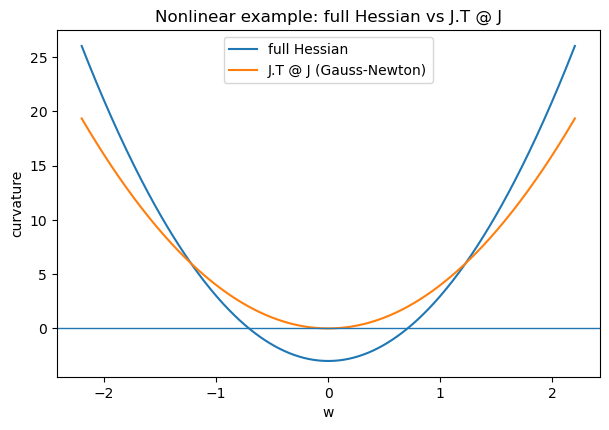

In [12]:

def y_nl(w):
    return w**2

def loss_nl(w, yhat=1.5):
    return 0.5 * (y_nl(w) - yhat)**2

def hessian_full_nl(w, yhat=1.5):
    return 4*w**2 + 2*(w**2 - yhat)

def gauss_newton_nl(w):
    return (2*w)**2

ws = np.linspace(-2.2, 2.2, 400)
H_full = hessian_full_nl(ws)
H_gn = gauss_newton_nl(ws)

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(ws, H_full, label="full Hessian")
ax.plot(ws, H_gn, label="J.T @ J (Gauss-Newton)")
ax.axhline(0, linewidth=1)
ax.set_title("Nonlinear example: full Hessian vs J.T @ J")
ax.set_xlabel("w")
ax.set_ylabel("curvature")
ax.legend()
plt.show()



### Gauss-Newton

对平方损失：

$$\mathcal L(\mathbf w)=\frac12\|\mathbf y(\mathbf w)-\hat{\mathbf y}\|^2$$

完整 Hessian 为：

$$\mathbf H = \mathbf J^\top \mathbf J + \sum_{i=1}^m r_i \nabla_{\mathbf w}^2 y_i$$

Gauss-Newton 近似就是：

$$\boxed{ \mathbf H_{\text{GN}} \approx \mathbf J^\top \mathbf J }$$

也就是把第二项扔掉。



###  什么时候合理

- 情况 1：输出本身接近线性
如果 $y_i(\mathbf w)$ 对局部参数变化近似线性，那么

$$\nabla_{\mathbf w}^2 y_i \approx 0$$

第二项本来就小。

- 情况 2：已经接近拟合点
如果残差很小：

$$r_i \approx 0$$

即使 $\nabla_{\mathbf w}^2 y_i$ 不为 0，第二项整体也会变小。

所以 Gauss-Newton 在“**局部拟合较好**”或“**模型局部近似线性**”时尤其合理。



## 总结

| # | 名称 | 公式 |
|---|------|------|
| 1 | 损失 | $\mathcal L(\mathbf w)=\frac12\|\mathbf y(\mathbf w)-\hat{\mathbf y}\|^2$ |
| 2 | 残差 | $\mathbf r=\mathbf y-\hat{\mathbf y}$ |
| 3 | Jacobian | $\mathbf J = \frac{\partial \mathbf y}{\partial \mathbf w^\top} \in \mathbb R^{m\times p}$ |
| 4 | 一阶导 | $\nabla_{\mathbf w}\mathcal L = \mathbf J^\top \mathbf r$ （输出空间 → 参数空间） |
| 5 | 完整 Hessian | $\mathbf H = \mathbf J^\top \mathbf J + \sum_i r_i \nabla_{\mathbf w}^2 y_i$ |
| 6 | 线性层简化 | $\nabla_{\mathbf w}^2 y_i = 0 \;\Rightarrow\; \mathbf H = \mathbf J^\top \mathbf J$ |
| 7 | Empirical Fisher | $\mathbf F_{\text{emp}} = \mathbf J^\top \mathbf J \approx \mathbf H$（当 $r_i$ 小或模型近线性时） |

**线性层 + vec 形式：** $\mathbf w=\operatorname{vec}(\mathbf W)$

$$\mathbf y=(\mathbf x^\top\otimes \mathbf I_m)\mathbf w \;\Rightarrow\; \mathbf J=\mathbf x^\top\otimes \mathbf I_m, \quad \mathbf H=(\mathbf x\mathbf x^\top)\otimes \mathbf I_m$$

**Hessian trace 与梯度能量：**

$$\operatorname{tr}(\mathbf H)=m\|\mathbf x\|^2, \qquad \left\|\frac{\partial \mathcal L}{\partial \mathbf W}\right\|_F^2 = \|\boldsymbol\delta\|^2\|\mathbf x\|^2$$

输入能量和误差信号能量都会直接放大参数敏感度。
